<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Accuracy: 0.8995633187772926
[[191  10]
 [ 13  15]]


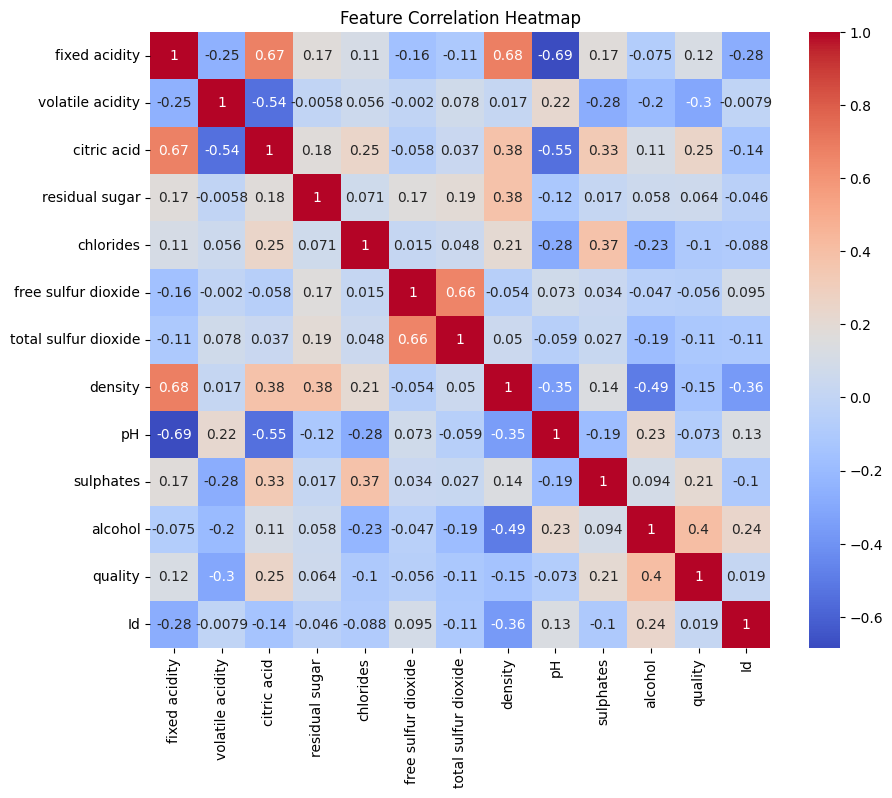

In [6]:
import pandas as pd
df= pd.read_csv('WineQT.csv')
df.head()
df.describe()
df.info()
df['quality']= df['quality'].apply(lambda x:1 if x >=7 else 0)
df['quality'].value_counts()
X= df.drop('quality', axis=1)
Y= df['quality']
X.head()
Y.head()
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)
X_train.shape, X_test.shape
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)
from sklearn.linear_model import LogisticRegression
model= LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)
Y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(Y_test, Y_pred)
print(cm)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()